In [272]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
from pathlib import Path 
import shutil

#Data loading and Plotting

In [273]:
Path.cwd()

WindowsPath('d:/Kaggle/HousePricesPrediction')

In [274]:
path = Path.cwd() /"Data"/"test.csv"
df = pd.read_csv(path)
df.head()
# print(df.shape)
df.isnull().sum().sum()
df.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           4
LotFrontage      227
LotArea            0
                ... 
MiscVal            0
MoSold             0
YrSold             0
SaleType           1
SaleCondition      0
Length: 80, dtype: int64

In [275]:
df.MSSubClass.isnull().sum()

np.int64(0)

In [276]:
missing_cols = []
def find_null_columns(df,missing_cols):
    for col in df.columns:
        if df[col].isnull().sum() > 0:
            missing_cols.append(col)
find_null_columns(df,missing_cols)
len(missing_cols) #so 33 have at least one missing data

33

In [277]:
missing_dic = {}
def find_avg_missing(miss,missing_dic):
    for col in miss:
        missing_dic[col] = (df[col].isnull().sum()/df.shape[0])*100
find_avg_missing(missing_cols,missing_dic)
for p in missing_dic:
    print(f"{p} percentage:{missing_dic[p]}")

MSZoning percentage:0.2741603838245374
LotFrontage percentage:15.558601782042494
Alley percentage:92.66620973269363
Utilities percentage:0.1370801919122687
Exterior1st percentage:0.06854009595613435
Exterior2nd percentage:0.06854009595613435
MasVnrType percentage:61.27484578478409
MasVnrArea percentage:1.0281014393420151
BsmtQual percentage:3.015764222069911
BsmtCond percentage:3.0843043180260454
BsmtExposure percentage:3.015764222069911
BsmtFinType1 percentage:2.878684030157642
BsmtFinSF1 percentage:0.06854009595613435
BsmtFinType2 percentage:2.878684030157642
BsmtFinSF2 percentage:0.06854009595613435
BsmtUnfSF percentage:0.06854009595613435
TotalBsmtSF percentage:0.06854009595613435
BsmtFullBath percentage:0.1370801919122687
BsmtHalfBath percentage:0.1370801919122687
KitchenQual percentage:0.06854009595613435
Functional percentage:0.1370801919122687
FireplaceQu percentage:50.03427004797807
GarageType percentage:5.20904729266621
GarageYrBlt percentage:5.346127484578479
GarageFinish pe

In [278]:
df["BsmtFullBath"].isnull().mean()

np.float64(0.0013708019191226869)

In [279]:
def rmv_more(missing_dic,df):
    for col in missing_dic:
        if df[col].isnull().mean()*100 > 50:
            print(col)
            df.drop(columns=col,inplace=True)
rmv_more(missing_dic,df)
len(df.columns)
miss_left = []
find_null_columns(df,miss_left)
miss_left
len(miss_left)


Alley
MasVnrType
FireplaceQu
PoolQC
Fence
MiscFeature


27

In [280]:
missing_dic = {}
find_avg_missing(miss_left,missing_dic)
len(missing_dic)
print(missing_dic)

{'MSZoning': np.float64(0.2741603838245374), 'LotFrontage': np.float64(15.558601782042494), 'Utilities': np.float64(0.1370801919122687), 'Exterior1st': np.float64(0.06854009595613435), 'Exterior2nd': np.float64(0.06854009595613435), 'MasVnrArea': np.float64(1.0281014393420151), 'BsmtQual': np.float64(3.015764222069911), 'BsmtCond': np.float64(3.0843043180260454), 'BsmtExposure': np.float64(3.015764222069911), 'BsmtFinType1': np.float64(2.878684030157642), 'BsmtFinSF1': np.float64(0.06854009595613435), 'BsmtFinType2': np.float64(2.878684030157642), 'BsmtFinSF2': np.float64(0.06854009595613435), 'BsmtUnfSF': np.float64(0.06854009595613435), 'TotalBsmtSF': np.float64(0.06854009595613435), 'BsmtFullBath': np.float64(0.1370801919122687), 'BsmtHalfBath': np.float64(0.1370801919122687), 'KitchenQual': np.float64(0.06854009595613435), 'Functional': np.float64(0.1370801919122687), 'GarageType': np.float64(5.20904729266621), 'GarageYrBlt': np.float64(5.346127484578479), 'GarageFinish': np.float6

In [281]:
cat_missing = [col for col in miss_left if df[col].dtype == "object"]
num_missing = [col for col in miss_left if df[col].dtype != "object"]

#Plotting the missing datas

In [282]:
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope',
       'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
       'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle',
       'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrArea', 'ExterQual',
       'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure',
       'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF',
       'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical',
       '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath',
       'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr',
       'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF',
       'Enclo

In [283]:
df.drop(columns="Utilities",inplace=True)
cat_missing.remove("Utilities")

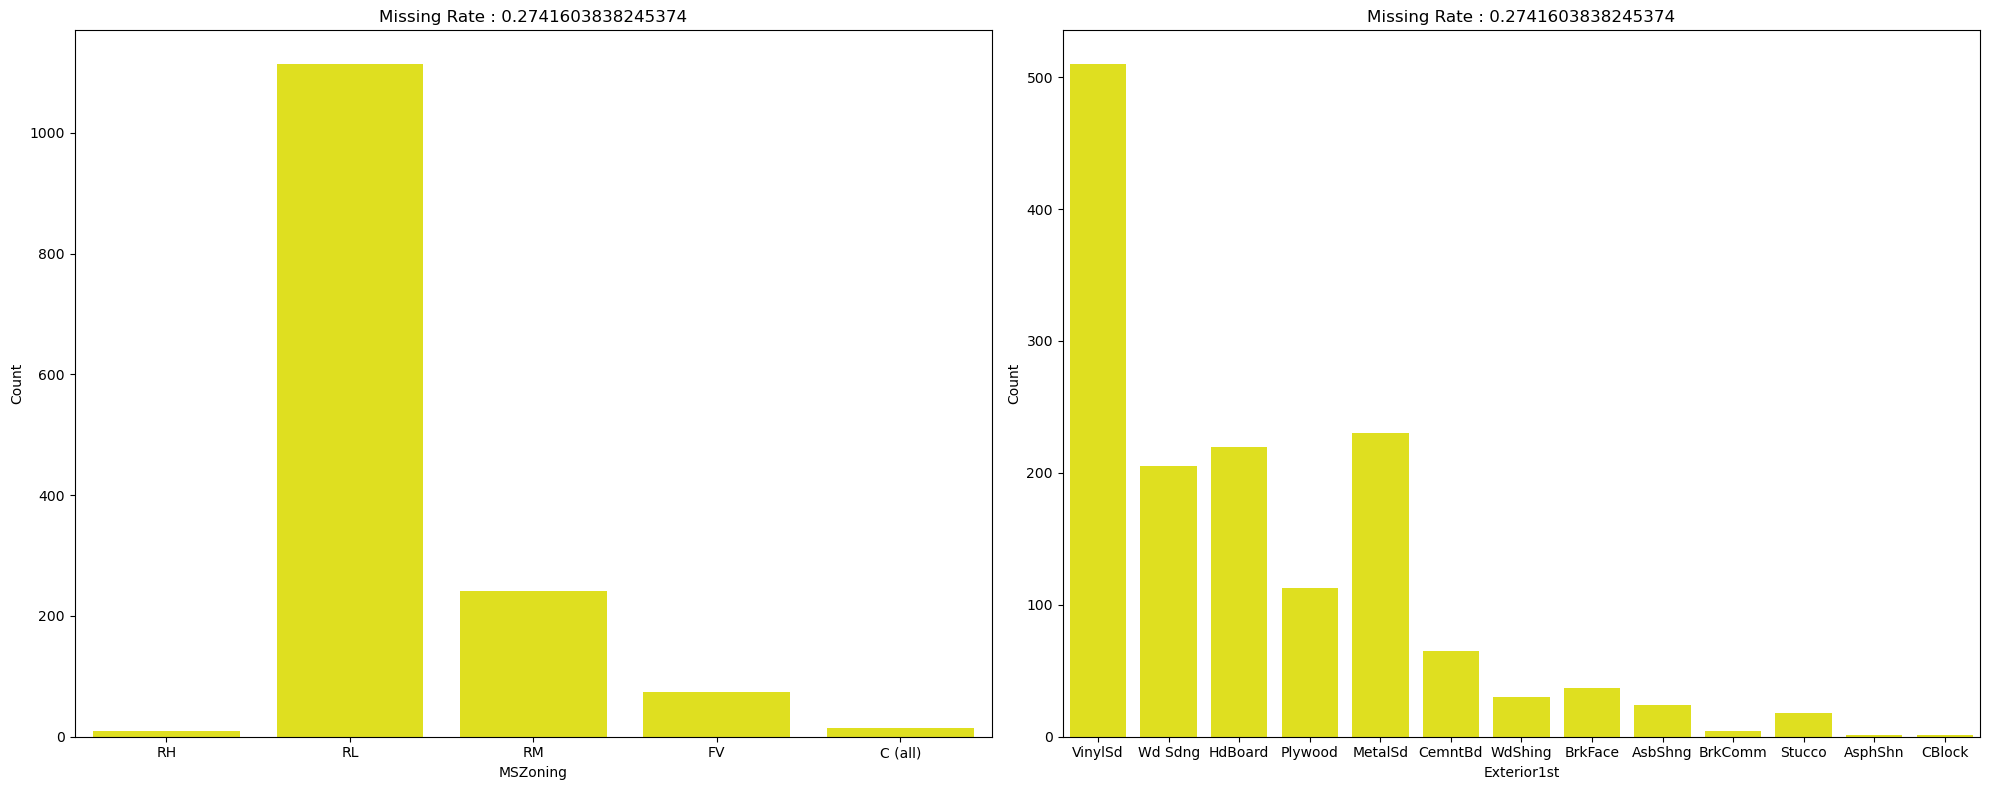

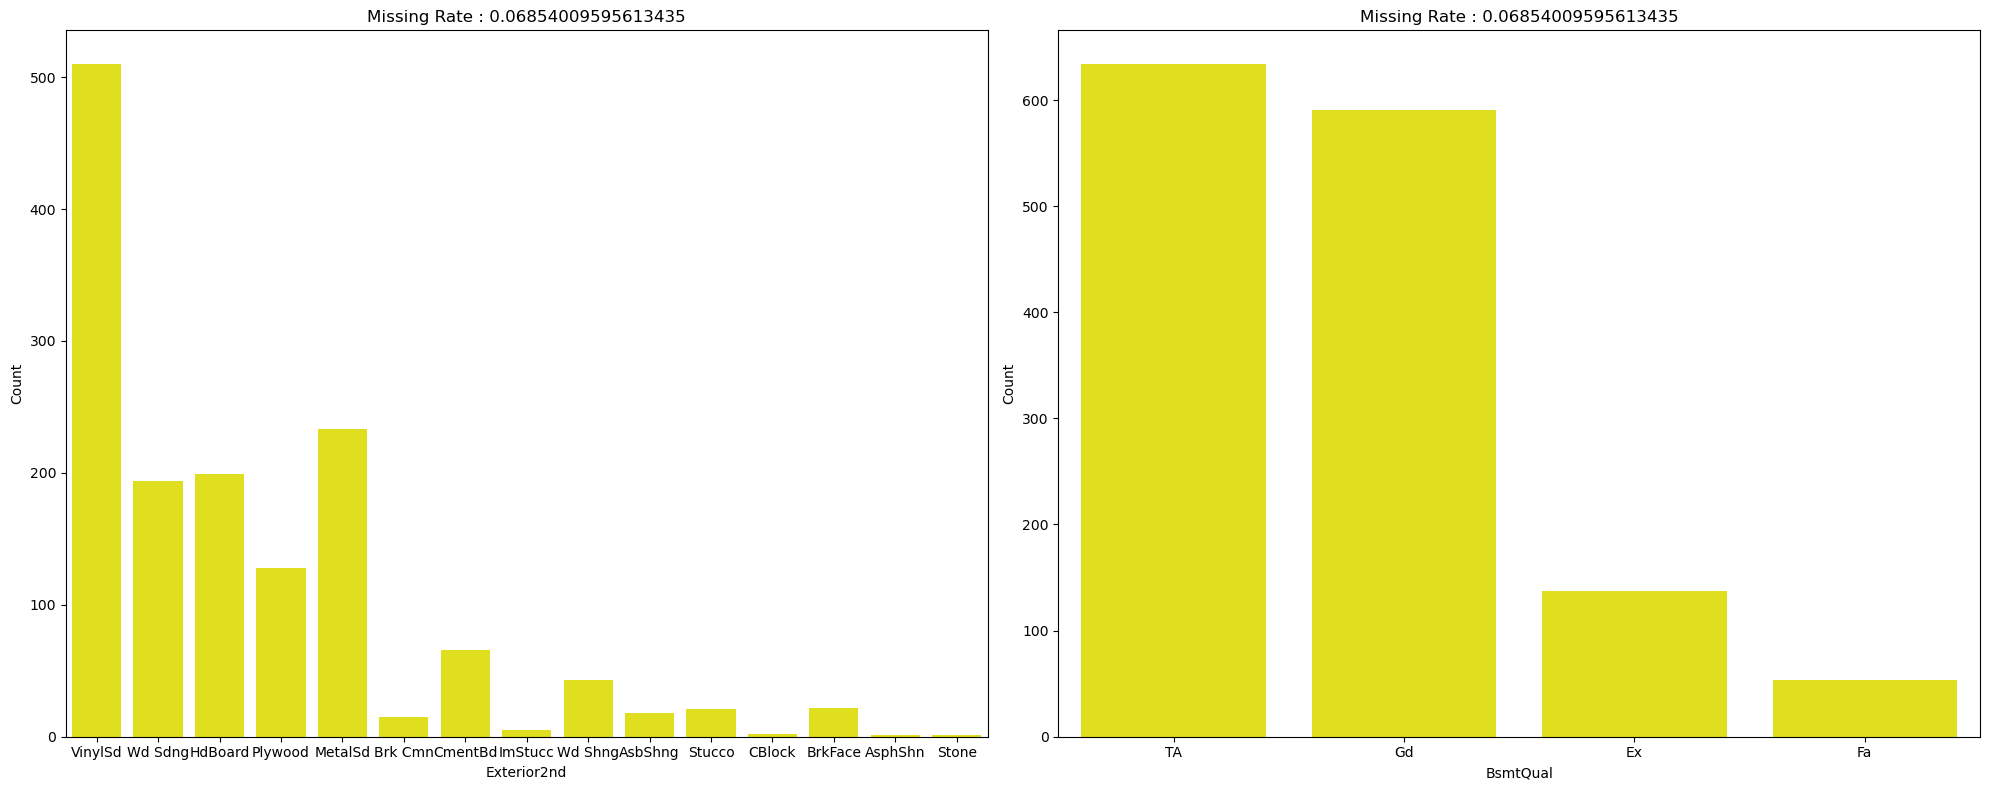

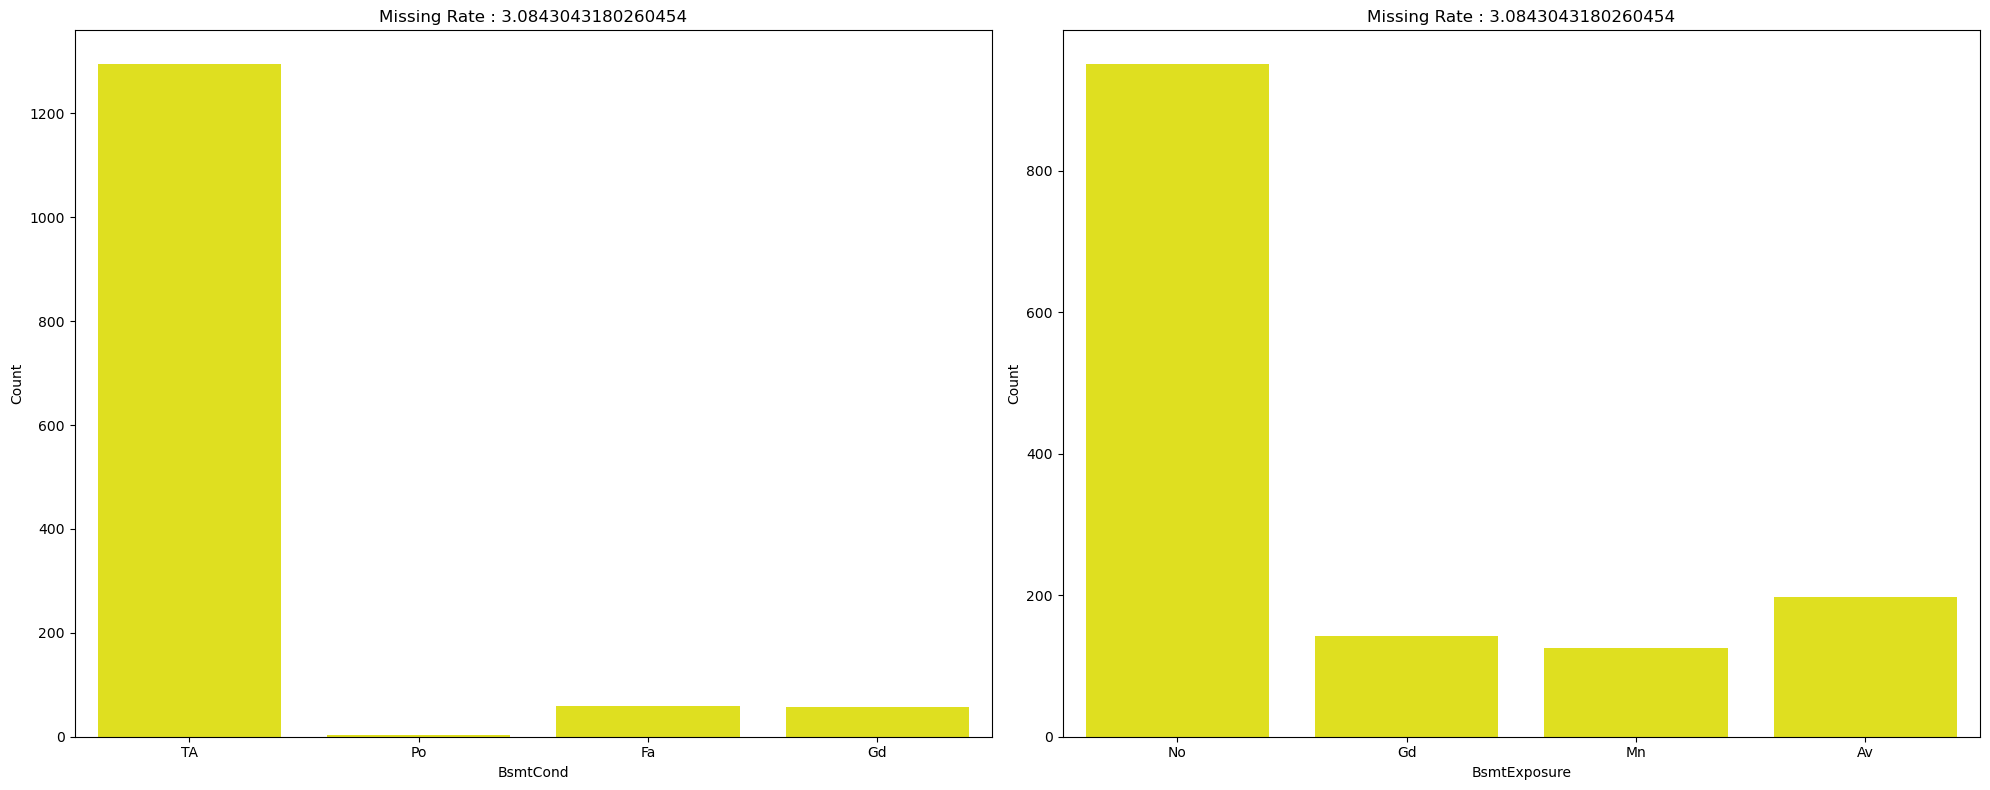

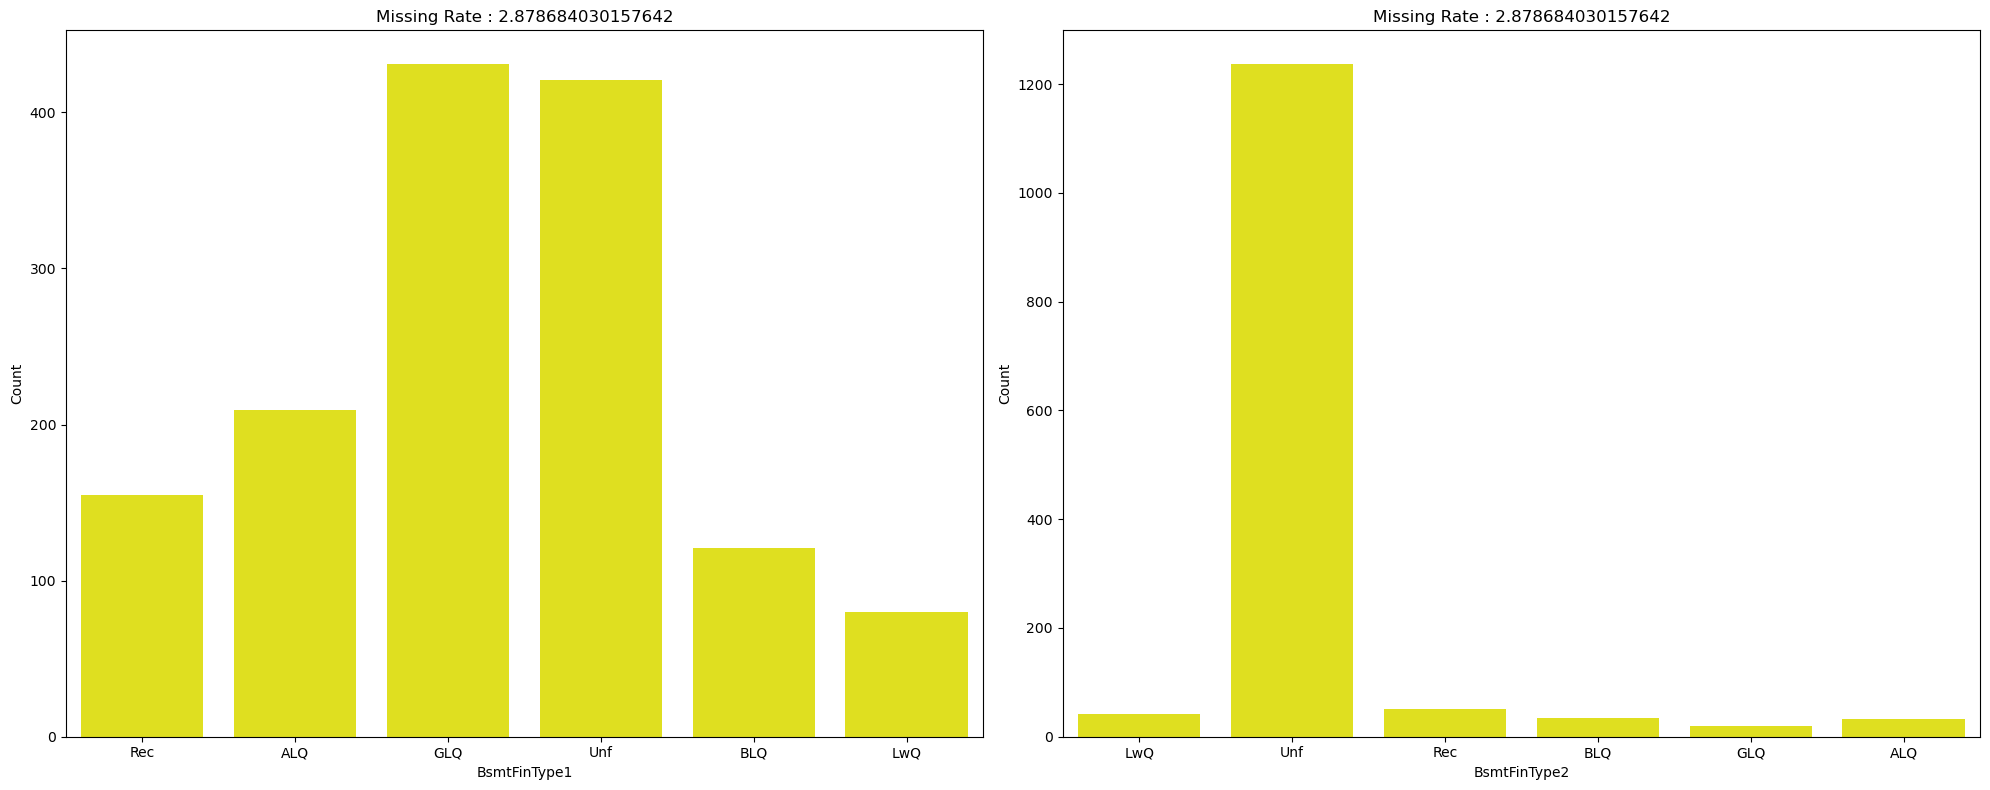

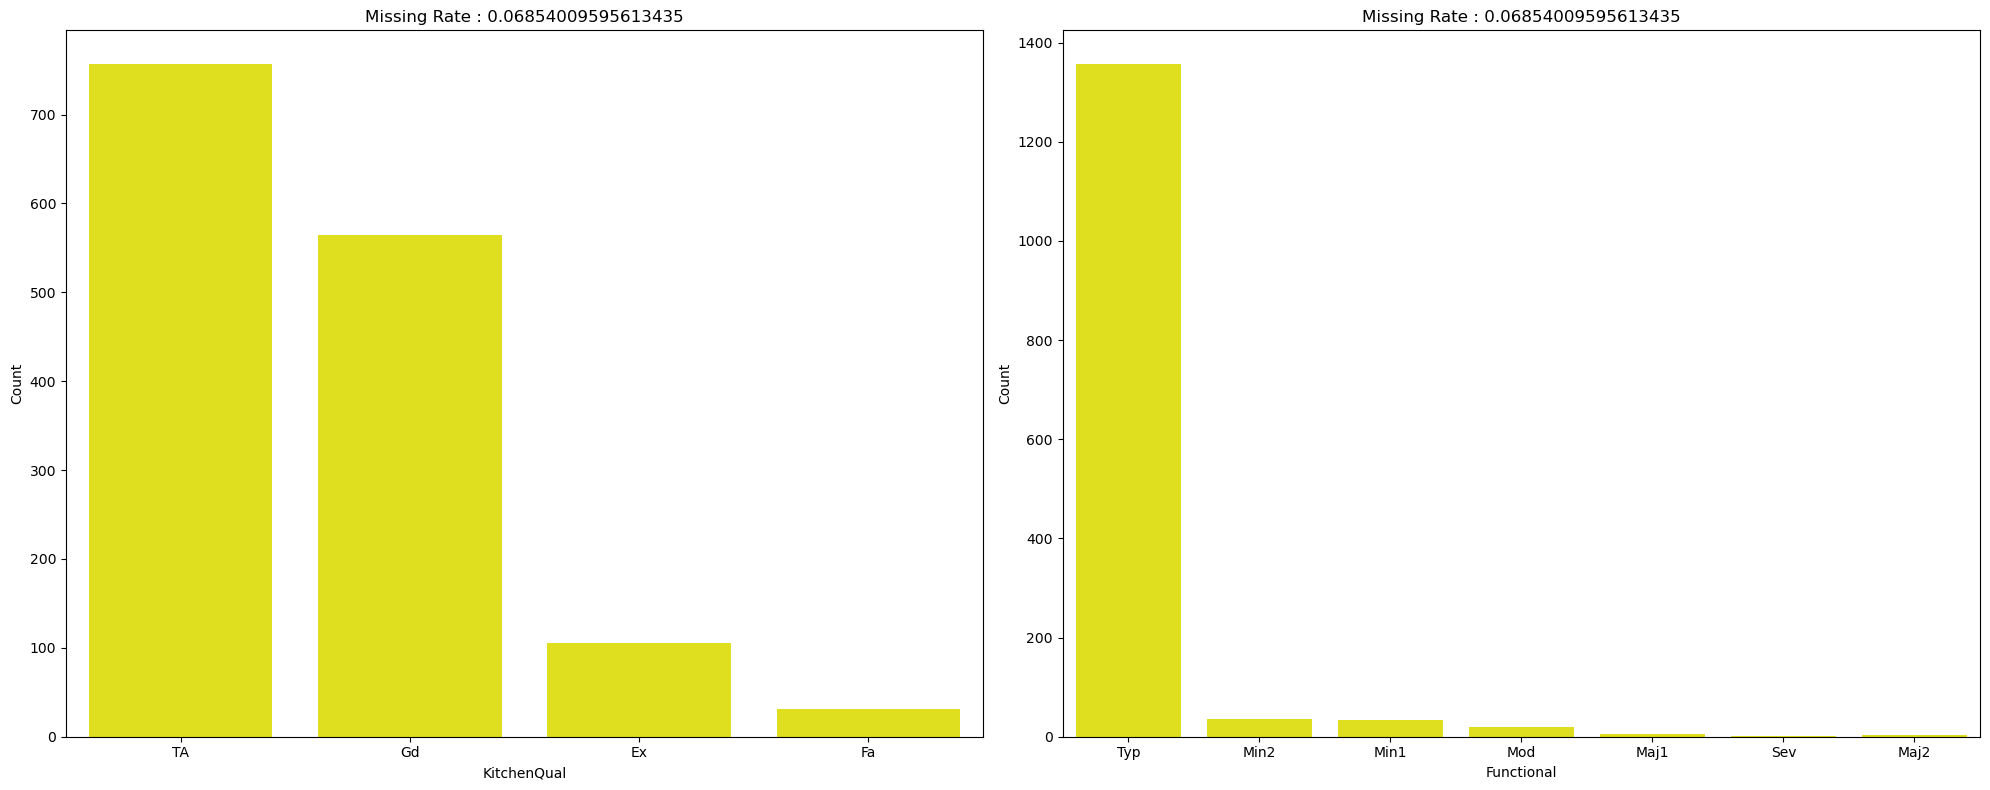

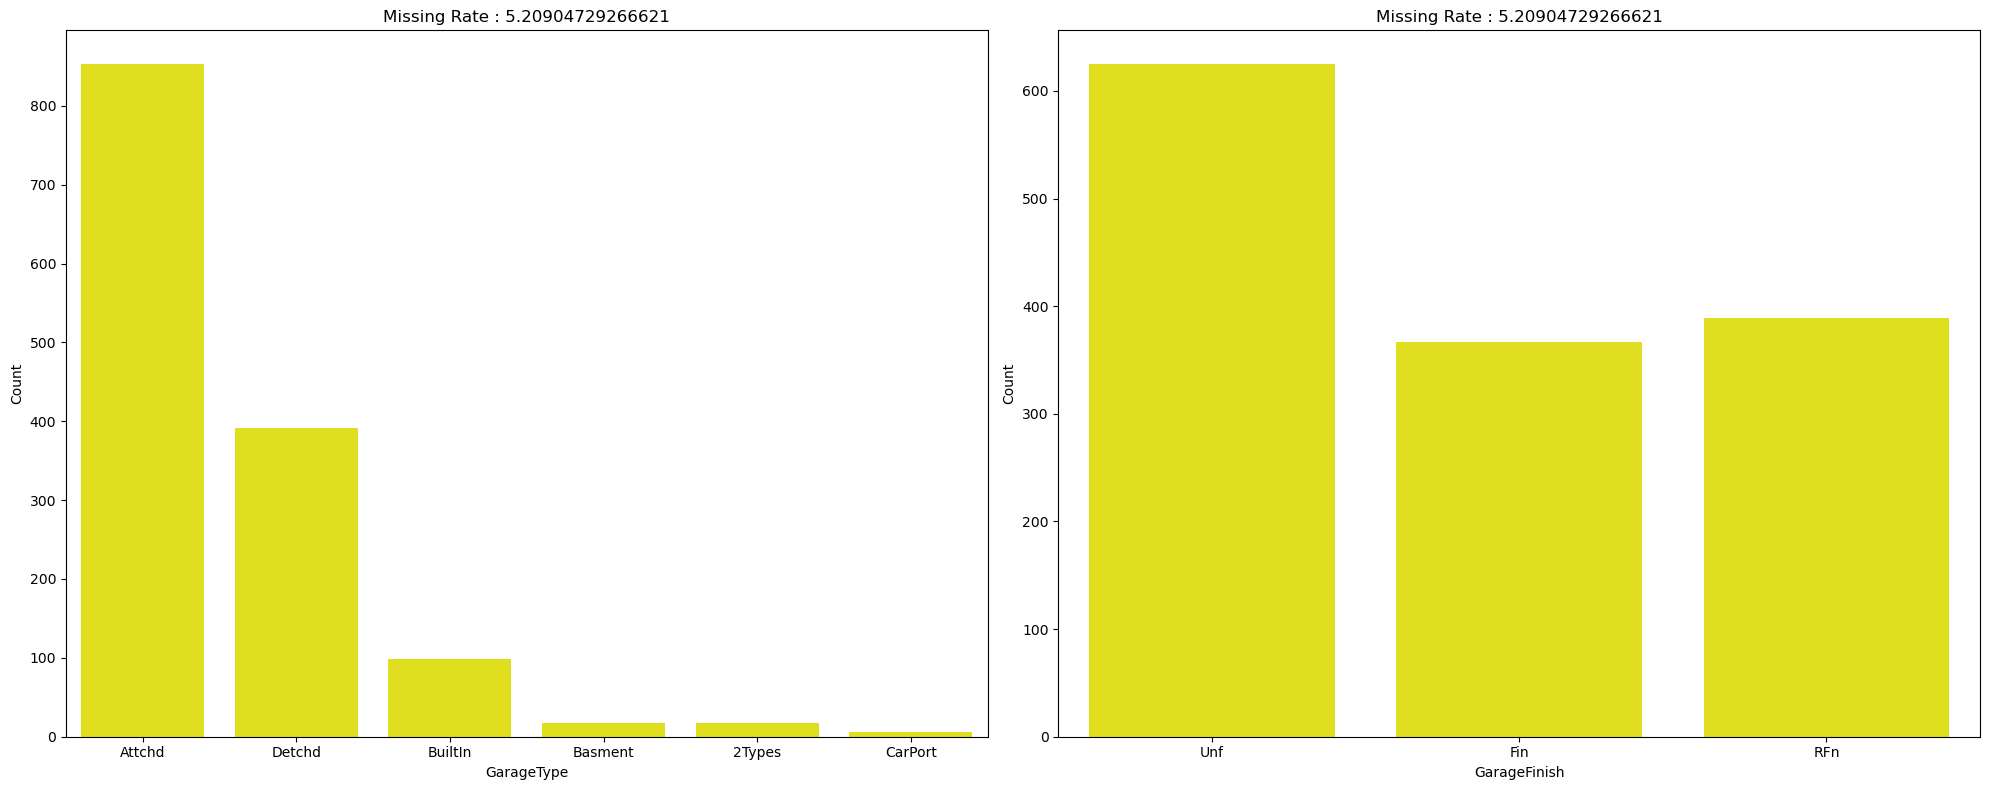

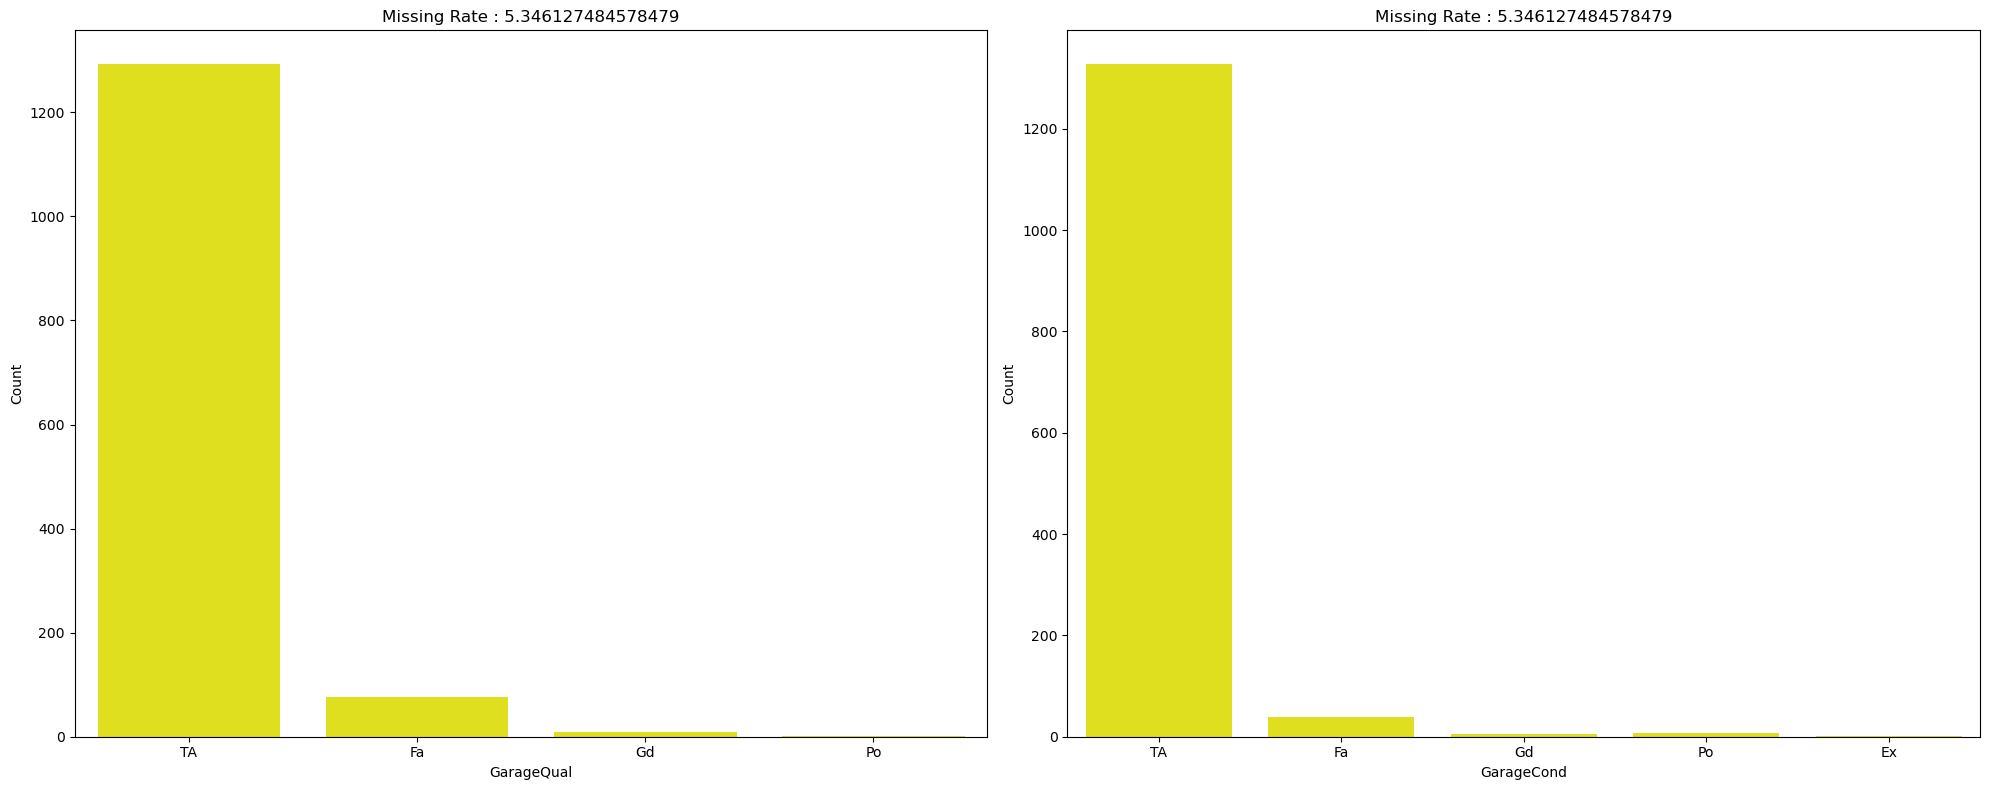

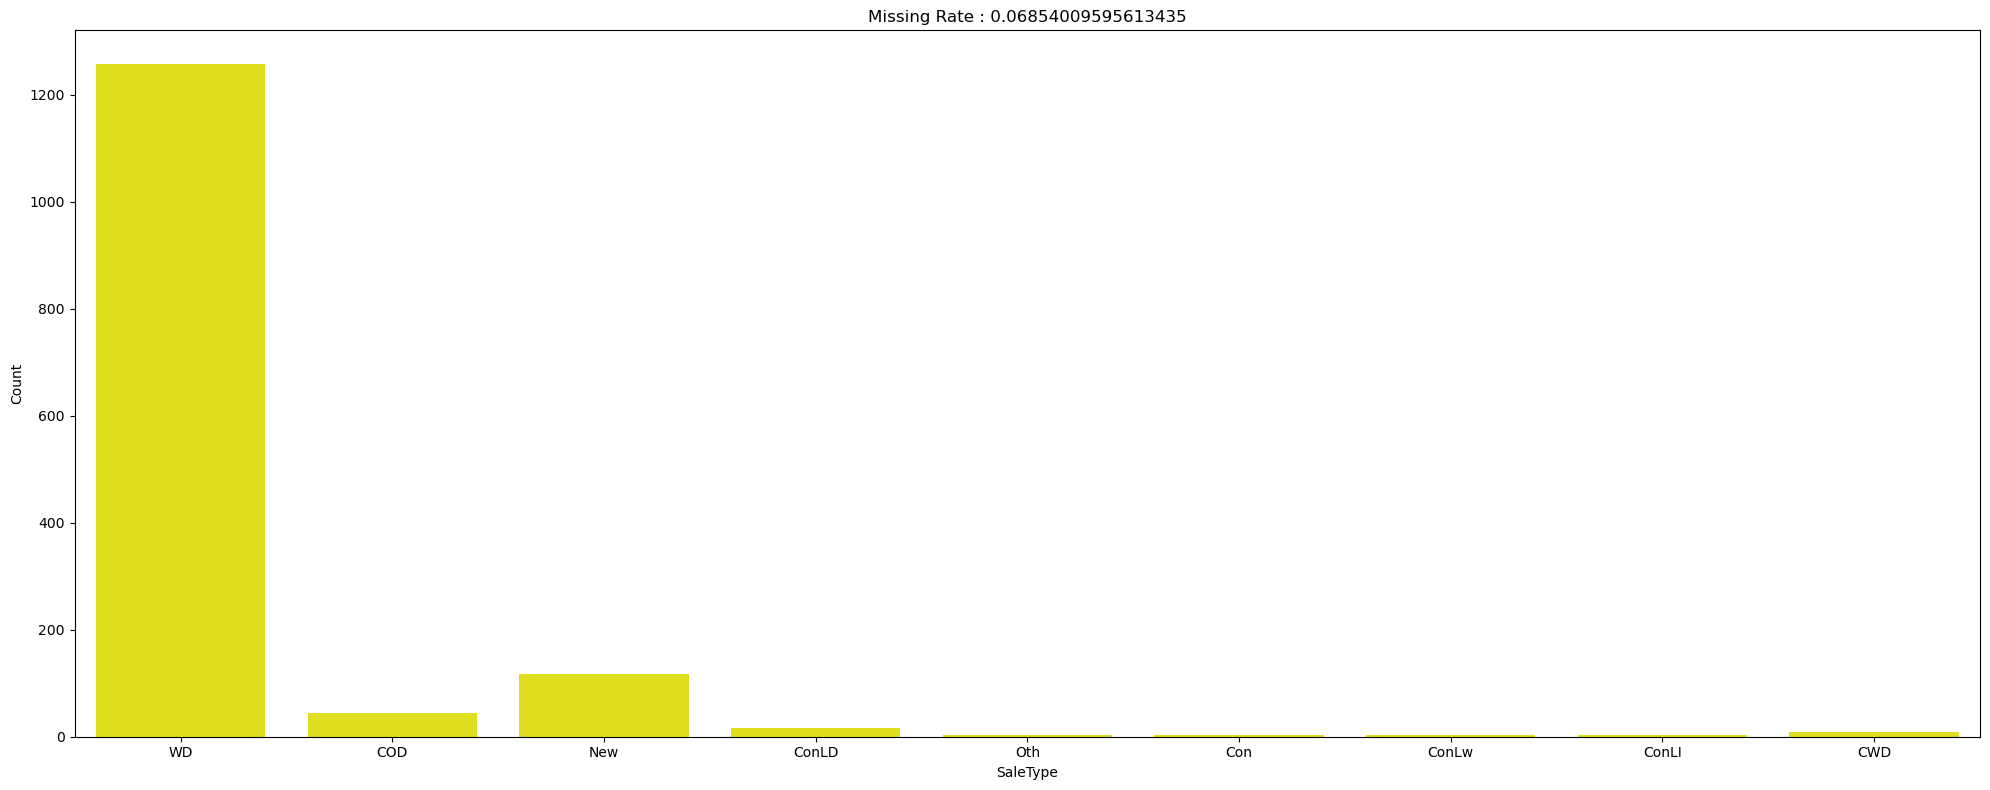

In [284]:

# plt.subplot(121)
for index in range(0,len(cat_missing),2):
    plt.figure(figsize=(20,8))
    if index == (len(cat_missing)-1):
       plt.subplot(1,1,1)
       sns.countplot(df,x=cat_missing[index],color='yellow')
       plt.xlabel(f"{cat_missing[index]}")
       plt.ylabel("Count")
       plt.title(f"Missing Rate : {missing_dic[cat_missing[index]]}")
       plt.tight_layout()
       plt.show()
    else:
      plt.subplot(1,2,1)
      sns.countplot(df,x=cat_missing[index],color='yellow')
      plt.xlabel(f"{cat_missing[index]}")
      plt.ylabel("Count")
      plt.title(f"Missing Rate : {missing_dic[cat_missing[index]]}")
      plt.subplot(1,2,2)
      sns.countplot(df,x=cat_missing[index+1],color='yellow')
      plt.xlabel(f"{cat_missing[index+1]}")
      plt.ylabel("Count")
      plt.title(f"Missing Rate : {missing_dic[cat_missing[index]]}")
      plt.tight_layout()
      plt.show()
    


In [285]:
cat_missing

['MSZoning',
 'Exterior1st',
 'Exterior2nd',
 'BsmtQual',
 'BsmtCond',
 'BsmtExposure',
 'BsmtFinType1',
 'BsmtFinType2',
 'KitchenQual',
 'Functional',
 'GarageType',
 'GarageFinish',
 'GarageQual',
 'GarageCond',
 'SaleType']

In [286]:
type(cat_missing)

list

In [291]:
X_cat_miss = df.loc[:,cat_missing]
type(X_cat_miss)

pandas.core.frame.DataFrame

In [ ]:
# ! pip install missingno

<Figure size 7000x5000 with 0 Axes>

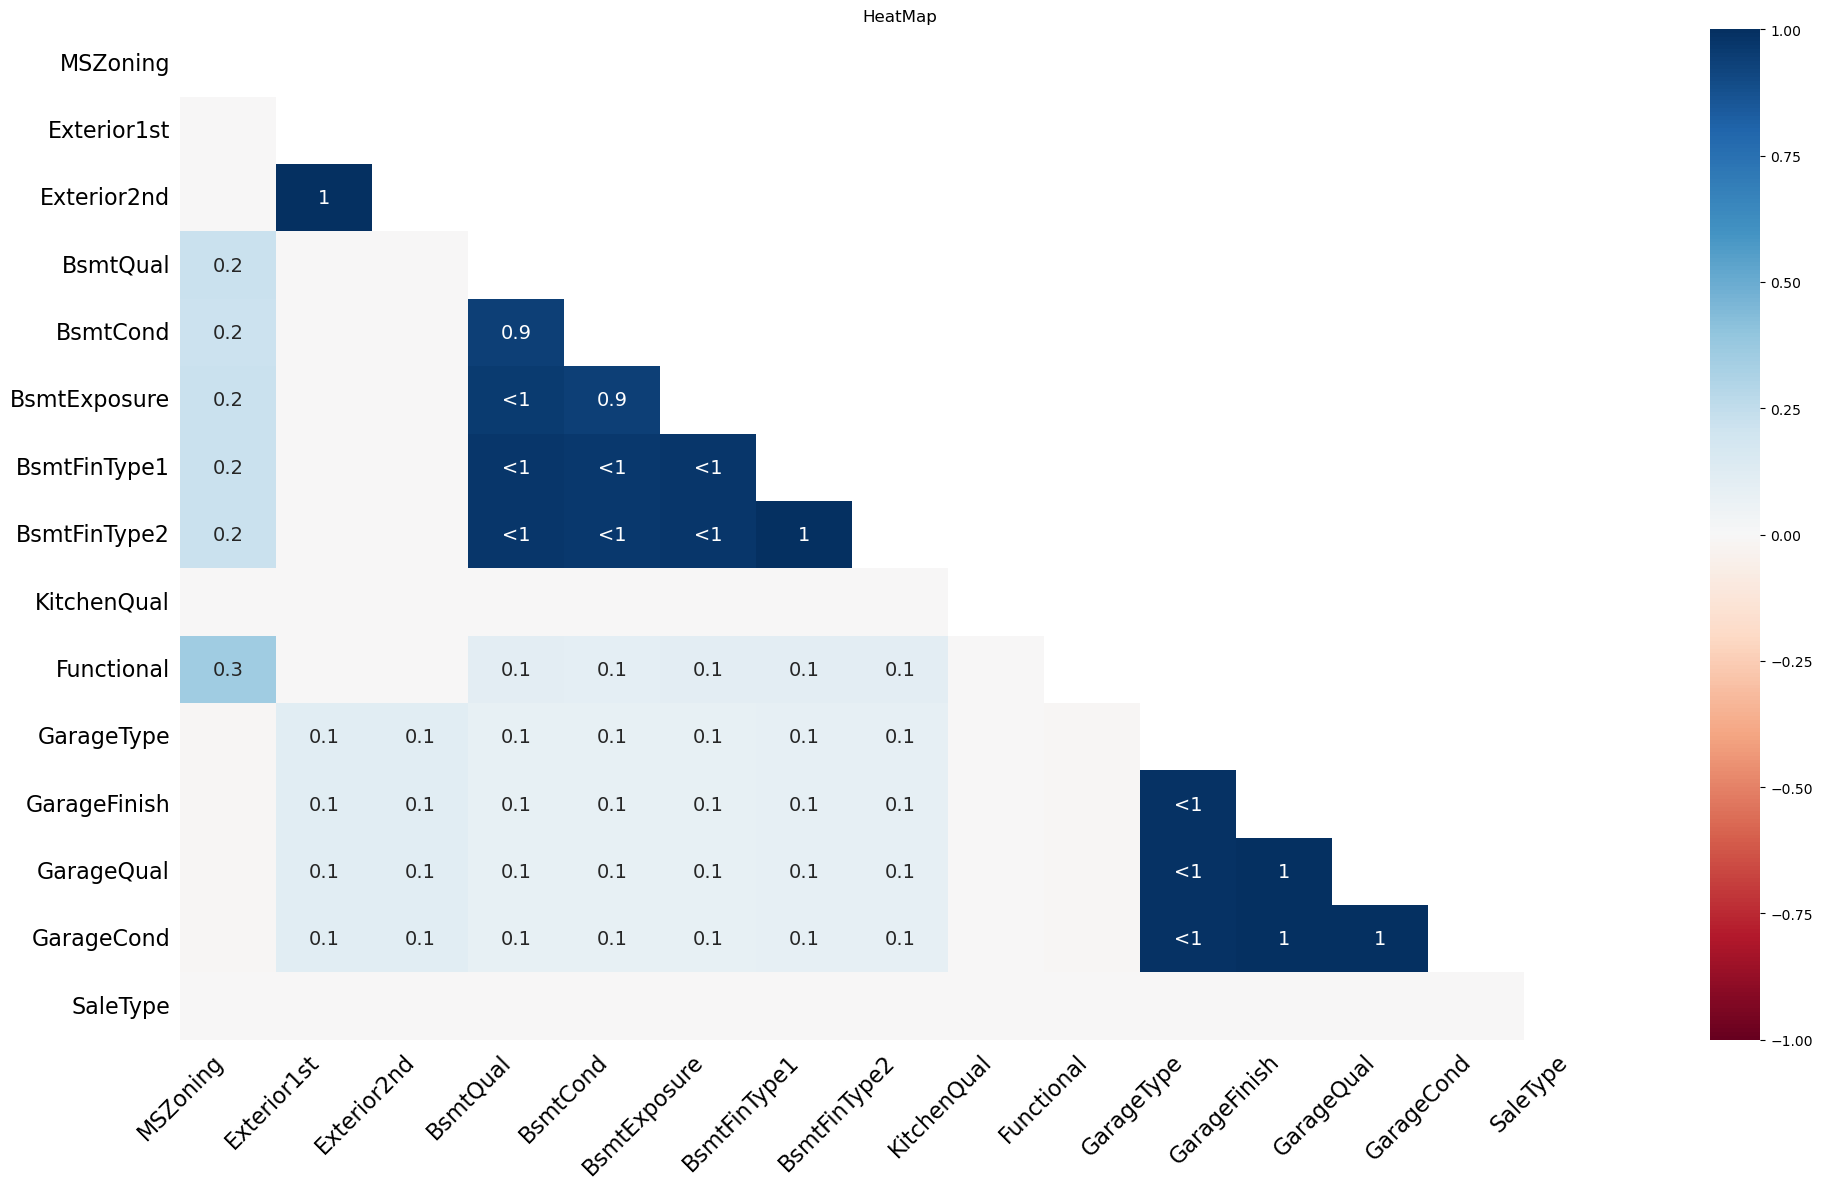

In [300]:
#heatmap 
import missingno as msno
# corr = X_cat_miss.corr()
plt.figure(figsize=(70,50))
msno.heatmap(X_cat_miss)
plt.title("HeatMap")
plt.tight_layout() 
plt.show()

From the heatmap it's evident that basements are missing together and garage too so they can be called Missing at Ranom

In [ ]:
#imputing the missing categorical columns
